## Importando Bibliotecas

In [28]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

### Carregando Dados

In [29]:
df = pd.read_csv('../../data/base_funcionarios_v4.csv')
df.head()

,Unnamed: 0,Salario,Anos_Educ_Superior,Tempo_Empresa,Tempo_de_Carreira,Possui_Skill_Dados
0,0,5517.4,3,3,9.777079,Não
1,1,6399.9,4,6,3.765998,Não
2,2,6206.7,6,3,7.926264,Não
3,3,6060.6,4,5,2.233497,Não
4,4,6122.7,2,9,26.821842,Não


## Limpeza e Preparação

### Visão Inicial dos dados

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          46 non-null     int64  
 1   Salario             46 non-null     float64
 2   Anos_Educ_Superior  46 non-null     int64  
 3   Tempo_Empresa       46 non-null     int64  
 4   Tempo_de_Carreira   46 non-null     float64
 5   Possui_Skill_Dados  46 non-null     str    
dtypes: float64(2), int64(3), str(1)
memory usage: 2.3 KB


### Removendo Colunas

In [31]:
df = df.drop(columns='Unnamed: 0')
df.head()

,Salario,Anos_Educ_Superior,Tempo_Empresa,Tempo_de_Carreira,Possui_Skill_Dados
0,5517.4,3,3,9.777079,Não
1,6399.9,4,6,3.765998,Não
2,6206.7,6,3,7.926264,Não
3,6060.6,4,5,2.233497,Não
4,6122.7,2,9,26.821842,Não


### Checando se há valores faltantes ou duplicados

In [32]:
df.isna().sum()

Salario               0
Anos_Educ_Superior    0
Tempo_Empresa         0
Tempo_de_Carreira     0
Possui_Skill_Dados    0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

### Verificando se as medidas resumo fazem sentido

In [34]:
df.describe()

,Salario,Anos_Educ_Superior,Tempo_Empresa,Tempo_de_Carreira
count,46.000000,46.000000,46.000000,46.000000
mean,6969.797826,5.065217,10.326087,21.194106
std,1924.868873,2.839422,7.601328,15.869038
min,4139.500000,0.000000,0.000000,-3.235467
25%,5818.350000,4.000000,5.250000,9.621697
50%,6394.750000,5.000000,8.500000,17.689876
75%,7972.400000,6.000000,17.250000,29.773380
max,12118.100000,12.000000,27.000000,67.858714


#### Problema: Tempo_de_Carreira < 0

In [35]:
df.loc[df['Tempo_de_Carreira'] < 0]

,Salario,Anos_Educ_Superior,Tempo_Empresa,Tempo_de_Carreira,Possui_Skill_Dados
19,5072.4,4,0,-3.235467,Não


Correção: transformar valores negativos em zero.

In [36]:
df.loc[df['Tempo_de_Carreira'] < 0, 'Tempo_de_Carreira'] = 0

### Criando variável dummy para a coluna "Possui_Skill_Dados"

In [37]:
df = pd.get_dummies(df, drop_first=True, dtype=int)
df.head()

,Salario,Anos_Educ_Superior,Tempo_Empresa,Tempo_de_Carreira,Possui_Skill_Dados_Sim
0,5517.4,3,3,9.777079,0
1,6399.9,4,6,3.765998,0
2,6206.7,6,3,7.926264,0
3,6060.6,4,5,2.233497,0
4,6122.7,2,9,26.821842,0


## Análise Exploratória de Dados

### Visal Geral do Relacionamento entre as variáveis

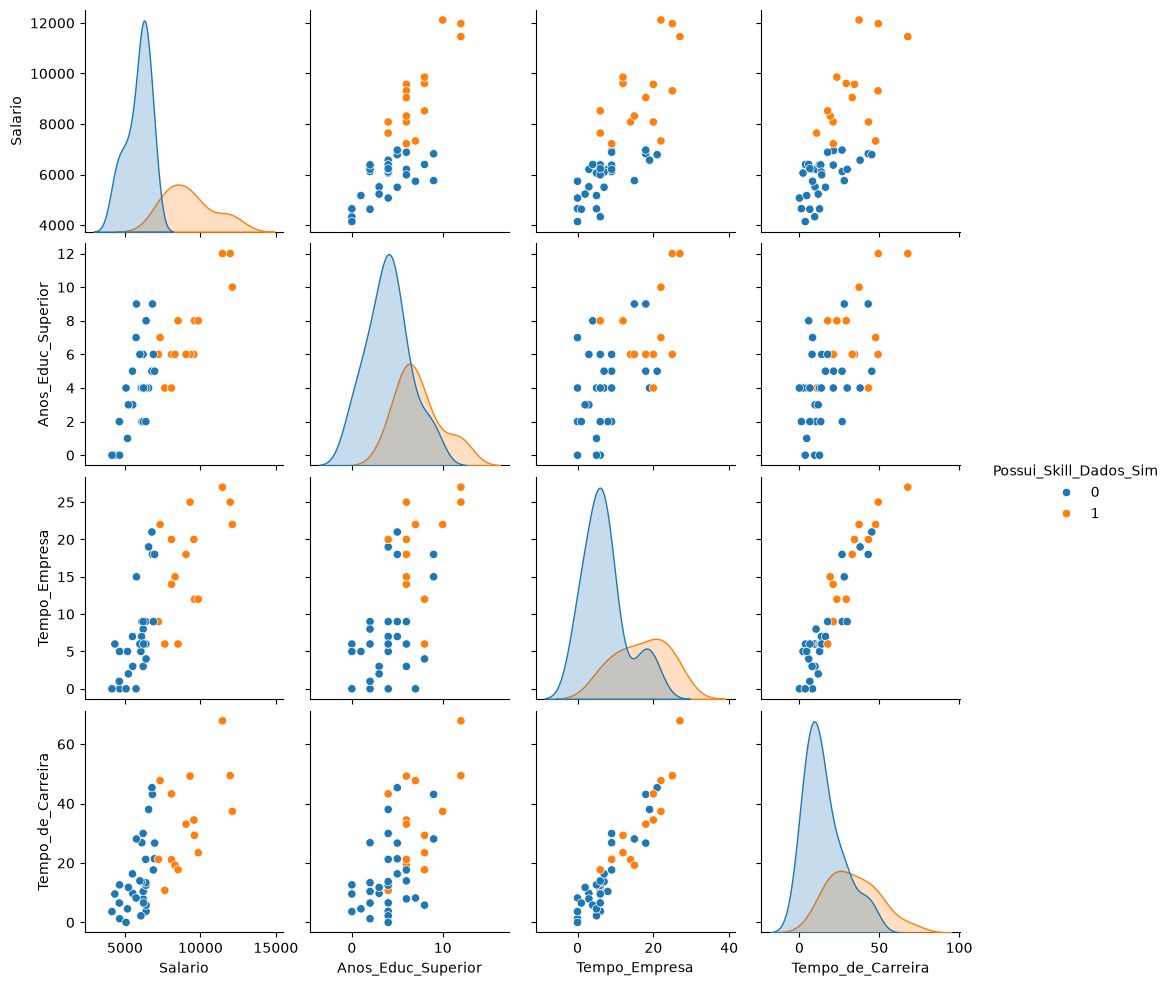

In [38]:
sns.pairplot(df, hue='Possui_Skill_Dados_Sim')

### Analisando a Correlação entre as variáveis (método Pearson)

<Axes: >

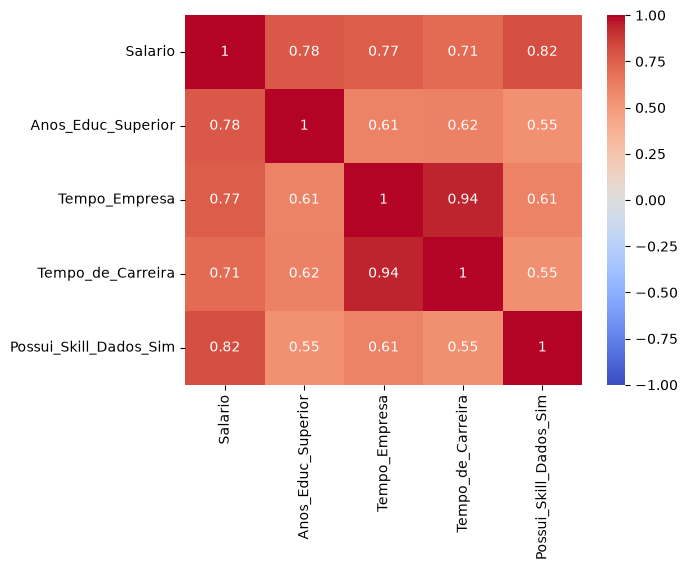

In [40]:
sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True, cmap='coolwarm')

## Treinando um modelo de Regressão Linear

In [41]:
# definindo o target
y = df['Salario']

# definindo as features + intercepto
df['Intercepto'] = 1
x = df.drop(columns='Salario')

In [42]:
# Ajustando o modelo
modelo = sm.OLS(y, x)
resultado = modelo.fit()

In [43]:
# Analisando resultados
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                Salario   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     66.28
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           2.37e-17
Time:                        16:22:11   Log-Likelihood:                -366.41
No. Observations:                  46   AIC:                             742.8
Df Residuals:                      41   BIC:                             752.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Anos_Educ_Superior       257

Apesar do modelo apresentar um desempenho bom, com um R² ajustado igual a 0.731, a feature "Tempo_de_Carreira" possui um p-valor alto. Vale a pena testar o desempenho de um modelo treinado sem ela.

In [44]:
# Ajustando as features
x = df.drop(columns=['Salario', 'Tempo_de_Carreira'])

# Treinando um novo modelo
modelo_ajustado = sm.OLS(y, x)
resultado_ajustado = modelo_ajustado.fit()

# Analisando os  resultados
print(resultado_ajustado.summary())

                            OLS Regression Results                            
Dep. Variable:                Salario   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     87.90
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           3.87e-18
Time:                        16:23:26   Log-Likelihood:                -366.99
No. Observations:                  46   AIC:                             742.0
Df Residuals:                      42   BIC:                             749.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Anos_Educ_Superior       247

O modelo não apresenta mudança no desempenho ao remover uma das features (R² ajustado: 0.853 -> 0.853).

### Equação do modelo:
Salário = $\beta_0$ + $\beta_1$ x Anos Educação Superior + $\beta_2$ x Tempo Empresa + $\beta_3$ x Possui Skill Dados (Sim)

<br>Onde:</br>
- $\beta_0$ = 4412.53
- $\beta_1$ = 247.88
- $\beta_2$ = 67.26
- $\beta_3$ = 1861.77

### Interpretação do Modelo
- $\beta_0$: Salário médio de um colaborador sem educação superior e recém chegado na empresa é de ``R$ 4412.53``
- $\beta_1$: Para cada **ano de educação superior** que o colaborador tem, mantendo o tempo de empresa constante, seu salário aumenta em média ``R$ 247.88``
- $\beta_2$: Para cada **ano que o colaborador está na empresa**, mantendo o tempo de educação superior constante, seu salário aumenta em média ``R$ 67.26``
- $\beta_3$: Se o funcionário possui habilidades técnicas na área de dados, mantendo os demais fatores constantes, seu salário tem um aumento médio de ``R$ 1861.77``